In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [ ]:
# 1. Download dataset
symbol = 'AAPL'  # Example: Apple Inc.
data = yf.download(symbol, start='2015-01-01', end='2024-12-31')

# Use only 'Close' price for prediction
close_prices = data['Close'].values.reshape(-1, 1)

/tmp/ipython-input-3-2033735436.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start='2015-01-01', end='2024-12-31')
[*********************100%***********************]  1 of 1 completed


In [ ]:
# 2. Normalize the data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(close_prices)

In [ ]:
# 3. Create sequences
def create_dataset(dataset, time_step=60):
    X, Y = [], []
    for i in range(len(dataset)-time_step-1):
        a = dataset[i:(i+time_step), 0]
        X.append(a)
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)

X = X.reshape(X.shape[0], X.shape[1], 1)

In [ ]:
# 4. Train-Test split
train_size = int(len(X) * 0.8)
test_size = len(X) - train_size
X_train, X_test = X[0:train_size], X[train_size:len(X)]
y_train, y_test = y[0:train_size], y[train_size:len(y)]

In [ ]:
# 5. Build LSTM model
model = Sequential()
model.add(LSTM(256, return_sequences=True, input_shape=(time_step, 1)))
model.add(LSTM(256))
model.add(Dropout(0.3))
model.add(Dense(32))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# 6. Train model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=90, batch_size=512, verbose=1)

Epoch 1/90
4/4 ━━━━━━━━━━━━━━━━━━━━ 25s 6s/step - accuracy: 2.0377e-04 - loss: 0.0499 - val_accuracy: 0.0020 - val_loss: 0.0512
Epoch 2/90
4/4 ━━━━━━━━━━━━━━━━━━━━ 37s 4s/step - accuracy: 5.2929e-04 - loss: 0.0128 - val_accuracy: 0.0020 - val_loss: 0.0738
Epoch 3/90
4/4 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 9.1992e-04 - loss: 0.0071 - val_accuracy: 0.0020 - val_loss: 0.0120
Epoch 4/90
4/4 ━━━━━━━━━━━━━━━━━━━━ 23s 4s/step - accuracy: 5.2929e-04 - loss: 0.0066 - val_accuracy: 0.0020 - val_loss: 0.0128
Epoch 5/90
4/4 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 3.3398e-04 - loss: 0.0028 - val_accuracy: 0.0020 - val_loss: 0.0179
Epoch 6/90
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 5.2929e-04 - loss: 0.0020 - val_accuracy: 0.0020 - val_loss: 0.0032
Epoch 7/90
4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 5.2929e-04 - loss: 0.0019 - val_accuracy: 0.0020 - val_loss: 9.6345e-04
Epoch 8/90
4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 3.3398e-04 - loss: 7.4521e-04 - val_accu

In [ ]:
# 7. Predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform to get actual prices
train_predict = scaler.inverse_transform(train_predict.reshape(-1,1))
y_train_actual = scaler.inverse_transform(y_train.reshape(-1,1))
test_predict = scaler.inverse_transform(test_predict.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 148ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step


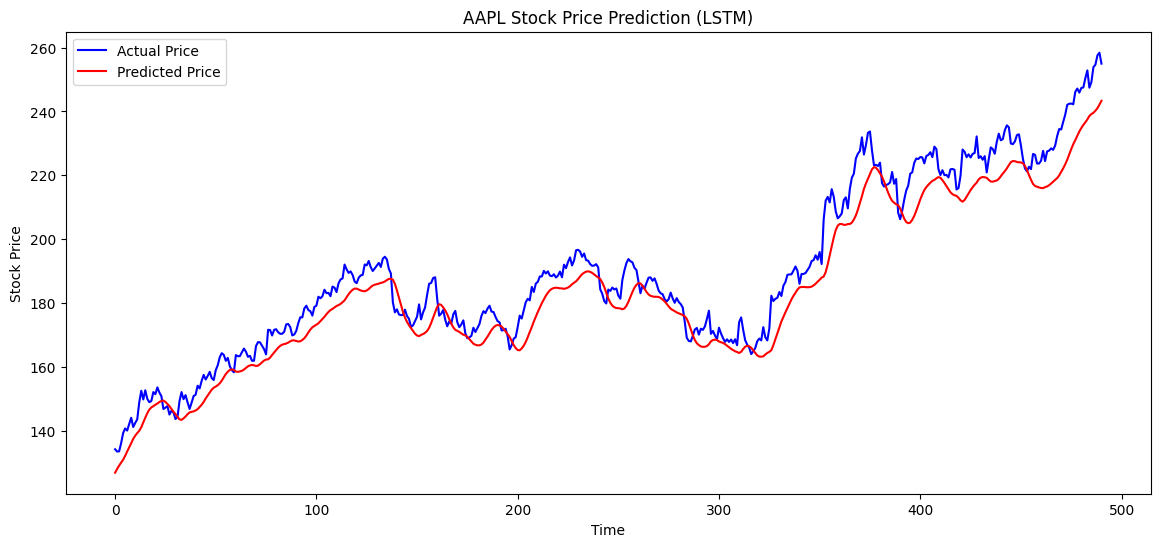

In [ ]:
# 8. Plot Actual vs. Predicted for Test data
plt.figure(figsize=(14,6))
plt.plot(y_test_actual, label='Actual Price', color='blue')
plt.plot(test_predict, label='Predicted Price', color='red')
plt.title(f'{symbol} Stock Price Prediction (LSTM)')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

In [ ]:
# 9. Calculate RMSE
train_rmse = np.sqrt(mean_squared_error(y_train_actual, train_predict))
test_rmse = np.sqrt(mean_squared_error(y_test_actual, test_predict))
print(f'Train RMSE: {train_rmse}')
print(f'Test RMSE: {test_rmse}')

Train RMSE: 3.1851191093903677
Test RMSE: 7.803472979474464
